In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler
#from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# data load(you should modify your file path!!)
selected_candidate_file_path = '/content/drive/MyDrive/Project2_K-means algorithm/Processed_Data_vertiport_candidates_scores.csv'

# read data
selected_candidate_df = pd.read_csv(selected_candidate_file_path)

# Remove duplicates
selected_candidate_df = selected_candidate_df.drop_duplicates(subset=['Latitude (deg)', 'Longitude (deg)'])

# remove 'NAN'
selected_candidate_df = selected_candidate_df.dropna()

# separate the value
# numpy_array
points = selected_candidate_df[['Longitude (deg)', 'Latitude (deg)']].to_numpy()
total_score = selected_candidate_df['Total_Score'].to_numpy()
total_score /= np.max(total_score)

# Pandas
lon=selected_candidate_df['Longitude (deg)']
lat=selected_candidate_df['Latitude (deg)']

In [ ]:
## Set parameters
# K: the number of centroids
K=17

# Separate cases to find best optimum solution from randomized initial centroids
initial_case = 50

# K-Means Clustering Implementation
max_iter = 100
tol = 1e-4
iterations_taken = 0

# ANN_exp
lon_max = max(lon)
lon_min = min(lon)
lat_max = max(lat)
lat_min = min(lat)

# Boundary
bounds = ((lon_min, lon_max), (lat_min, lat_max))

A = (lon_max - lon_min) * (lat_max - lat_min)
ann_exp = 0.5 / np.sqrt(K / A)

In [ ]:
## Define functions
# K-means Algorithm
def K_means(points, max_iter, centroids, K, tol = 1e-4):
  for iteration in range(max_iter):

    iterations_taken = iteration + 1


    clusters = []

    # Assign points to nearest centroid
    for point in points:

        # Calculate distance from point to each centroid
        distances = np.linalg.norm(point - centroids, axis=1)

        # Find nearest centroid index
        cluster = np.argmin(distances)

        clusters.append(cluster)

    clusters = np.array(clusters)

    # Update centroids by calculating mean of points in each cluster
    new_centroids = []

    for i in range(K):

        # Get all points in cluster i
        cluster_points = points[clusters == i]

        # Keep the centroid if a cluster becomes empty
        if len(cluster_points) == 0:
            new_centroid = centroids[i]
        else:
            # Calculate mean
            new_centroid = cluster_points.mean(axis=0)

        new_centroids.append(new_centroid)

    new_centroids = np.array(new_centroids)

    # Stop when centroids stop moving meaningfully
    if np.allclose(centroids, new_centroids, atol=tol):
        centroids = new_centroids
        break

    # Update centroid values
    centroids = new_centroids

  return centroids, clusters, iterations_taken

In [ ]:
def ANN_function(spots, K, A):

  distances_neighbor=[]

  # ANN_obs
  for spot in spots:
    distances = np.linalg.norm(spot - spots, axis=1)
    dist_neighbor = np.partition(distances, 1)[1]
    distances_neighbor.append(dist_neighbor)

  ann_obs = np.mean(distances_neighbor)

  # ANN_exp
  ann_exp = 0.5 / np.sqrt(K / A)

  R = ann_obs / ann_exp

  return R

In [ ]:
def train_poly_landscape_model(points, Total_Scores, degree=2):

  poly = PolynomialFeatures(degree=degree)
  points_poly = poly.fit_transform(points)

  model = LinearRegression()
  model.fit(points_poly, Total_Scores)

  return model, poly

In [ ]:
def get_poly_score(single_coord, model, poly):

  coord_poly = poly.transform([single_coord])
  return model.predict(coord_poly)[0]

In [ ]:
def get_poly_gradient(model, poly, single_coord, epsilon=1e-5):

  lon, lat = single_coord[0], single_coord[1]

  # Gradient on longitude
  s_lon_plus = get_poly_score([lon + epsilon, lat], model, poly)
  s_lon_minus = get_poly_score([lon - epsilon, lat], model, poly)
  grad_lon = (s_lon_plus - s_lon_minus) / (2 * epsilon)

  # Gradient on latitude
  s_lat_plus = get_poly_score([lon, lat + epsilon], model, poly)
  s_lat_minus = get_poly_score([lon, lat - epsilon], model, poly)
  grad_lat = (s_lat_plus - s_lat_minus) / (2 * epsilon)

  return np.array([grad_lon, grad_lat])

In [ ]:
def optimize_centroids_poly(model, poly, single_old_centroid, learning_rate=0.001, iterations=1000):
  new_centroid = np.array(single_old_centroid, dtype = float)

  for _ in range(iterations):
      grad = get_poly_gradient(model, poly, new_centroid)
      new_centroid += learning_rate * grad # Gradient ascent!! not descent

      new_centroid[0] = np.clip(new_centroid[0], bounds[0][0], bounds[0][1])
      new_centroid[1] = np.clip(new_centroid[1], bounds[1][0], bounds[1][1])

  return new_centroid

In [ ]:
def evaluation(location_df, centroids, clusters, K):
  loc = location_df[['Longitude (deg)', 'Latitude (deg)']].to_numpy()
  dist_sqrt_sum = 0

  for i in range(K):
    loc_cluster = loc[clusters == i]
    dist_sqrt = np.linalg.norm(loc_cluster - centroids[i], axis=1) ** 2

    dist_sqrt_sum += np.sum(dist_sqrt)

  return dist_sqrt_sum

In [ ]:
## evaluation function to select the case
def evaluation_case(points, score_df, k1, k2):
  R_case = ANN_function(points, K, A)

  mean_score_case = (score_df).mean()

  return k1 * mean_score_case + k2 * R_case




In [ ]:
## Select the final vertiport
def finding_near_point(points, clusters, finalized_centroids, K):


  selected_vertiport_location = []

  for i in range(K):
    final_cluster_point = points[clusters == i]

    if len(final_cluster_point) == 0:
          continue

    distances = np.linalg.norm(final_cluster_point - finalized_centroids[i], axis=1)

    # Find nearest centroid index
    min_idx = np.argmin(distances)
    selected_vertiport_location.append(final_cluster_point[min_idx])

  selected_vertiport_location = np.array(selected_vertiport_location)

  selected_longitude = []
  selected_latitude = []
  selected_score = []

  for point in selected_vertiport_location:
    condition = np.isclose(selected_candidate_df['Longitude (deg)'], point[0]) & \
                  np.isclose(selected_candidate_df['Latitude (deg)'], point[1])

    selected_longitude.append(points[condition, 0][0])
    selected_latitude.append(points[condition, 1][0])
    selected_score.append(total_score[condition][0])

  selected_vertiport_data_df = pd.DataFrame({
      'Longitude (deg)': selected_longitude,
      'Latitude (deg)': selected_latitude,
      'Total Score': selected_score
  })

  return selected_vertiport_data_df

In [ ]:
## Find the optimum process
k1=7
k2=3

# Scaling 0~3
k1 = (k1 / (k1 + k2)) * 3
k2 = (k2 / (k1 + k2)) * 3

df_selected_list = []
clusters_list = []
centroids_list = []
initial_centroids_list =[]
afterK_centroids_list = []
iteration_taken_list = []
evaluation_list = []

np.random.seed(42)

for i in range(initial_case):
  # Randomize inital cetroids
  random_indices = np.random.choice(len(points), K, replace=False)
  centroids = points[random_indices]

  initial_centroids = centroids

  # implement K-means algorithm
  result = K_means(points, max_iter, centroids, K, tol = 1e-4)

  Centroids = result[0]
  afterK_centroids = Centroids.copy()

  Clusters = result[1]
  iteration_taken = result[2]



  # Feedback Process
  for centroid in Centroids:
    R_array = []
    for point in points:
      # calcuration the score when a centroid moves other candidate point
      test_centroids = Centroids.copy()
      mask = np.all(test_centroids == centroid, axis=1)
      test_centroids[mask] = point

      R_array.append(ANN_function(test_centroids, K, A))

    R_array = np.array(R_array)
    R_array /= np.max(R_array)

    # Get a Feedback score from each point
    Feedback_array = k1 * total_score + k2 * R_array

    # Regression Process
    (poly_model, feed_poly) = train_poly_landscape_model(points, Feedback_array)

    # Gradient Ascent Algorithm
    new_centroid = optimize_centroids_poly(poly_model, feed_poly, centroid)

    idx = np.all(Centroids == centroid, axis=1)
    Centroids[idx] = new_centroid

  # optimum solution in case
  centroids = Centroids.copy()

  ## save the data
  # selected vertiport's Longitude, Latitude, Total score(each case in DataFrame)
  df_selected_vertiports = finding_near_point(points, Clusters, centroids, K)
  df_selected_list.append(df_selected_vertiports)

  selected_vertiport_points_df = df_selected_vertiports[['Longitude (deg)', 'Latitude (deg)']]
  selected_vertiport_points = np.array(selected_vertiport_points_df)

  # Finalized clusters(each case in column)
  clusters_list.append(Clusters)

  # After gradient ascent algoritm(each case in column)
  centroids_list.append(centroids)

  # Initial centroids(each case in column)
  initial_centroids_list.append(initial_centroids)

  # After K-means algorithm centroids(each case in column)
  afterK_centroids_list.append(afterK_centroids)

  # Iteration taken(each case in column)
  iteration_taken_list.append(iteration_taken)

  # ANN evaluation(each case in column)
  score_df = df_selected_vertiports['Total Score']
  evaluation_list.append(evaluation_case(selected_vertiport_points, score_df, k1, k2))

In [ ]:
## Select the optimum
optimum_case = evaluation_list.index(max(evaluation_list))

df_selected_vertiports = df_selected_list[optimum_case]
selected_vertiports_array = np.array(df_selected_vertiports[['Longitude (deg)', 'Latitude (deg)']])

clusters = np.array(clusters_list[optimum_case])
centroids = np.array(centroids_list[optimum_case])
initial_centroids = np.array(initial_centroids_list[optimum_case])
afterK_centroids = np.array(afterK_centroids_list[optimum_case])
iteration_taken = np.array(iteration_taken_list[optimum_case])

print('optimum case : {}'.format(optimum_case))
print('evaluation(0 ~ 6) : {}'.format(max(evaluation_list)))
print('')
print('Initial centroids : ')
print(initial_centroids)
print('')
print('after K-means centroids : ')
print(afterK_centroids)
print('')
print('After gradient ascent centroids : ')
print(centroids)
print('')
print('selected vertiport : ')
print(df_selected_vertiports.to_string())
print('')
print('iteration_taken during K-means algorithm : {}'.format(iteration_taken))

optimum case : 8
evaluation(0 ~ 6) : 2.7777795715404667

Initial centroids : 
[[128.06252899  35.04816993]
 [126.22453261  33.36111574]
 [127.30720028  36.33688329]
 [128.6315811   37.64318523]
 [127.47233249  36.20838577]
 [126.70426713  37.86652441]
 [127.02072873  37.19624812]
 [127.17494634  36.72241532]
 [126.92846784  35.20151131]
 [127.46110235  35.46591751]
 [127.54619494  36.52076411]
 [128.19066381  37.19850721]
 [128.65291071  35.88323093]
 [126.7177751   37.95889096]
 [127.97513351  36.91443717]
 [129.36915679  35.60549984]
 [128.18729904  37.63958   ]]

after K-means centroids : 
[[128.13072011  35.26316578]
 [126.57411774  33.38775248]
 [126.77779595  35.92640143]
 [128.60568726  37.42143036]
 [127.94929408  36.2185637 ]
 [126.76713295  37.54135647]
 [127.13681634  37.46501689]
 [126.77954128  36.74809776]
 [126.83596438  35.08104333]
 [127.40088582  35.60974371]
 [127.33025589  36.43040099]
 [129.03428298  36.60016254]
 [128.57222361  35.86447697]
 [127.37880157  37.8891

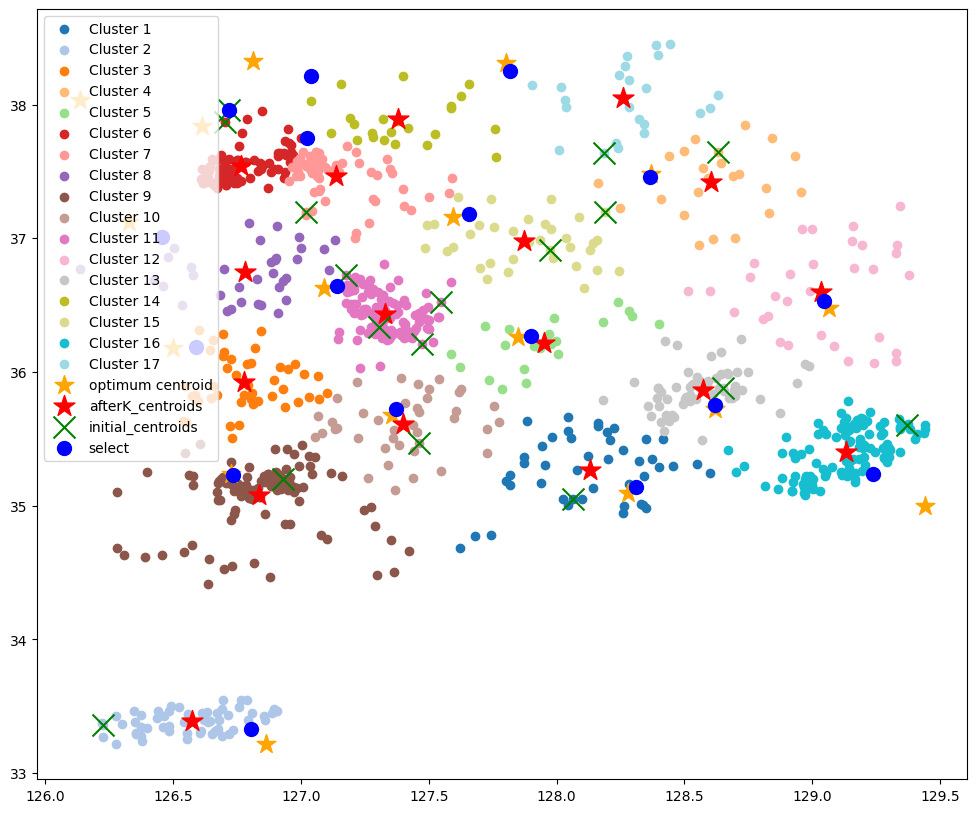

In [ ]:
colors = plt.cm.tab20(np.linspace(0, 1, K))
plt.figure(figsize=(12, 10))

for i in range(K):

    cluster_points = points[clusters == i]

    plt.scatter(
        cluster_points[:,0],
        cluster_points[:,1],
        color=colors[i],
        label=f'Cluster {i+1}'
    )

# Plot centroids
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    color='orange',
    marker='*',
    s=200,
    label='optimum centroid'
)

# Plot afterK centroids
plt.scatter(
    afterK_centroids[:,0],
    afterK_centroids[:,1],
    color='red',
    marker='*',
    s=250,
    label='afterK_centroids'
)

# Plot initial centroids
plt.scatter(
    initial_centroids[:,0],
    initial_centroids[:,1],
    color='green',
    marker='x',
    s=250,
    label='initial_centroids'
)

# Plot finally selected vertiport
plt.scatter(
    selected_vertiports_array[:,0],
    selected_vertiports_array[:,1],
    color='blue',
    marker='o',
    s=100,
    label='select'
)

plt.legend()
plt.grid(False)
plt.show()